## 1) Problem Statement
#### This project understands how the student's performance (test score) is affected by other variables such as gender, parental level of education, lunch and Test preparation course.

### Lifecycle of Machine Learning project
##### Understanding the problem statement
##### data collection
##### data checks to perform
##### exploratory data analysis
##### data preprocessing
##### model training
##### choose best model

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv('data/study.csv')

In [25]:
# for checking null values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [26]:
# For checking duplicate columns
df.duplicated().sum()


np.int64(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [28]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [29]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [31]:
## Exploring data
print("Categories in gender variable: ", end=" ")
print(df['gender'].unique())

print("Categories in gender variable: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in gender variable: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in gender variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in gender variable: ", end=" ")
print(df['test preparation course'].unique())

Categories in gender variable:  ['female' 'male']
Categories in gender variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in gender variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in gender variable:  ['standard' 'free/reduced']
Categories in gender variable:  ['none' 'completed']


In [32]:
## Defining numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print("{} Numerical features: {}".format(len(numeric_features), numeric_features))
print("{} Categorical features: {}".format(len(categorical_features), categorical_features))

3 Numerical features: ['math score', 'reading score', 'writing score']
5 Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [34]:
df['total score'] = df['math score']+df['reading score']+df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


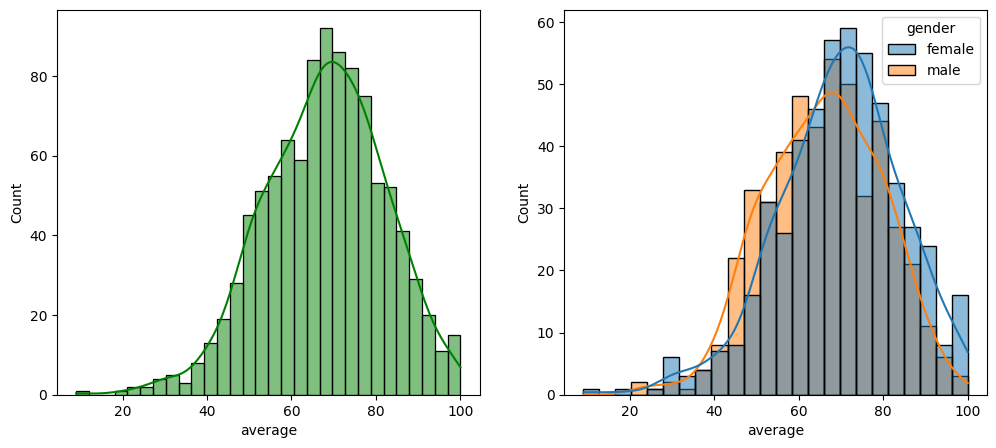

In [40]:
fig, axs=plt.subplots(1, 2, figsize=(12, 5))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.show()